In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [2]:
# 전체 사용자 중 실제 결제 사용자는 얼마나 되는가?
revenue_payer_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- Acquisition 기준과 동일한 유효 가입자
valid_users AS (
  SELECT DISTINCT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제 기록
successful_payments AS (
  SELECT DISTINCT
    hp.user_id
  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL

    -- 성공한 결제만 인정
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL

    -- 실제 스토어 결제번호가 있는 기록만 인정
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    -- 정상적인 유료 결제만 인정
    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    -- 분석기간 안에 완료된 결제만 인정
    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
)

SELECT
  COUNT(DISTINCT vu.user_id) AS total_user_count,

  COUNT(
    DISTINCT IF(
      sp.user_id IS NOT NULL,
      vu.user_id,
      NULL
    )
  ) AS payer_user_count,

  COUNT(
    DISTINCT IF(
      sp.user_id IS NULL,
      vu.user_id,
      NULL
    )
  ) AS non_payer_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          sp.user_id IS NOT NULL,
          vu.user_id,
          NULL
        )
      ),
      COUNT(DISTINCT vu.user_id)
    ) * 100,
    2
  ) AS payer_conversion_rate_percent,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          sp.user_id IS NULL,
          vu.user_id,
          NULL
        )
      ),
      COUNT(DISTINCT vu.user_id)
    ) * 100,
    2
  ) AS non_payer_rate_percent

FROM valid_users AS vu

LEFT JOIN successful_payments AS sp
  ON vu.user_id = sp.user_id
"""

In [3]:
cost(revenue_payer_sql)

예상 스캔량: 1.115 MiB
예상 스캔량: 0.001089 GiB
월 1 TiB 무료 용량의 약 0.00010634%


0.0010888772085309029

In [4]:
revenue_payer_df = (
    bq.query(revenue_payer_sql)
      .result()
      .to_dataframe()
)

revenue_payer_df

,total_user_count,payer_user_count,non_payer_user_count,payer_conversion_rate_percent,non_payer_rate_percent
0,18001,3246,14755,18.03,81.97


In [5]:
result = revenue_payer_df.iloc[0]

total_users = int(
    result["total_user_count"]
)

payer_users = int(
    result["payer_user_count"]
)

non_payer_users = int(
    result["non_payer_user_count"]
)

payer_rate = float(
    result["payer_conversion_rate_percent"]
)

non_payer_rate = float(
    result["non_payer_rate_percent"]
)

print("[Revenue · 실제 결제 사용자 분석]")
print(f"전체 유효 사용자: {total_users:,}명")
print(
    f"실제 결제 사용자: "
    f"{payer_users:,}명 ({payer_rate:.2f}%)"
)
print(
    f"비결제 사용자: "
    f"{non_payer_users:,}명 ({non_payer_rate:.2f}%)"
)
print()
print(
    f"전체 유효 사용자 {total_users:,}명 중 "
    f"{payer_users:,}명이 하트 상품을 한 번 이상 실제로 결제했으며, "
    f"전체 결제 전환율은 {payer_rate:.2f}%입니다."
)

[Revenue · 실제 결제 사용자 분석]
전체 유효 사용자: 18,001명
실제 결제 사용자: 3,246명 (18.03%)
비결제 사용자: 14,755명 (81.97%)

전체 유효 사용자 18,001명 중 3,246명이 하트 상품을 한 번 이상 실제로 결제했으며, 전체 결제 전환율은 18.03%입니다.


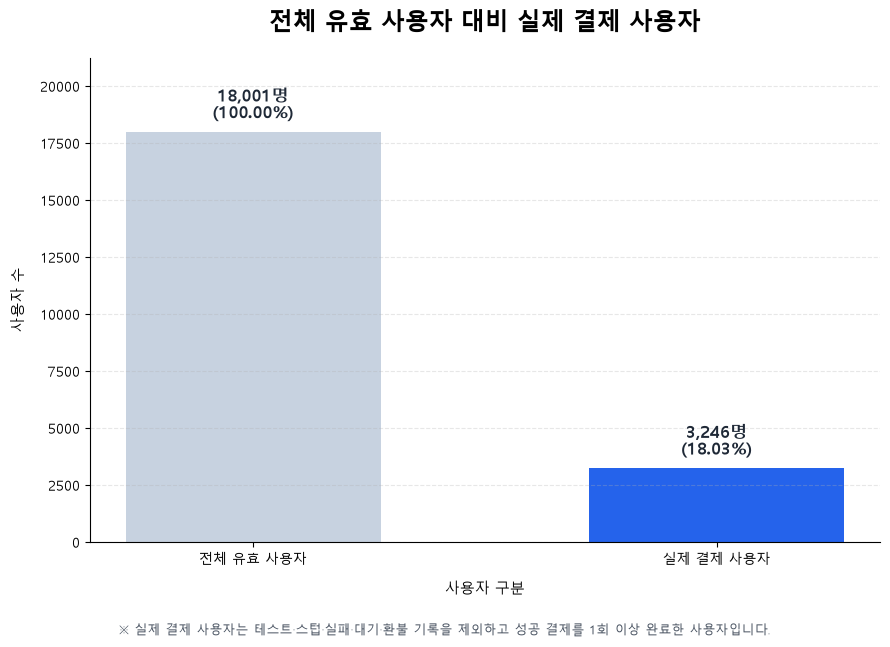

In [6]:
import platform
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 결과값 가져오기
# =========================================================

result = revenue_payer_df.iloc[0]

total_users = int(
    result["total_user_count"]
)

payer_users = int(
    result["payer_user_count"]
)

payer_rate = float(
    result["payer_conversion_rate_percent"]
)


# =========================================================
# 3. 막대그래프
# =========================================================

labels = [
    "전체 유효 사용자",
    "실제 결제 사용자"
]

values = [
    total_users,
    payer_users
]

rates = [
    100.0,
    payer_rate
]

colors = [
    "#C7D2E0",
    "#2563EB"
]

fig, ax = plt.subplots(
    figsize=(9, 6.5)
)

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.55
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, value, rate in zip(
    bars,
    values,
    rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_users * 0.025,
        f"{value:,}명\n({rate:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "전체 유효 사용자 대비 실제 결제 사용자",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "사용자 구분",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    total_users * 1.18
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    "※ 실제 결제 사용자는 테스트·스텁·실패·대기·환불 기록을 제외하고 성공 결제를 1회 이상 완료한 사용자입니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [7]:
# 가입 후 첫 결제까지 얼마나 걸리는가?
first_purchase_delay_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at

  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
),

-- 사용자별 최초 성공 결제
first_payment AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_payment_at

  FROM successful_payments
  GROUP BY user_id
)

SELECT
  vu.user_id,

  vu.signup_at,

  fp.first_payment_at,

  DATETIME(
    vu.signup_at,
    'Asia/Seoul'
  ) AS signup_datetime_kst,

  DATETIME(
    fp.first_payment_at,
    'Asia/Seoul'
  ) AS first_payment_datetime_kst,

  -- 가입 후 첫 결제까지 걸린 시간
  TIMESTAMP_DIFF(
    fp.first_payment_at,
    vu.signup_at,
    HOUR
  ) AS hours_to_first_purchase,

  -- 소수점 단위 일수
  ROUND(
    TIMESTAMP_DIFF(
      fp.first_payment_at,
      vu.signup_at,
      HOUR
    ) / 24.0,
    2
  ) AS days_to_first_purchase

FROM valid_users AS vu

INNER JOIN first_payment AS fp
  ON vu.user_id = fp.user_id

-- 가입보다 먼저 발생한 비정상 결제 기록 제외
WHERE fp.first_payment_at >= vu.signup_at

ORDER BY days_to_first_purchase
"""

In [8]:
cost(first_purchase_delay_sql)

예상 스캔량: 1.268 MiB
예상 스캔량: 0.001238 GiB
월 1 TiB 무료 용량의 약 0.00012090%


0.0012380601838231087

In [9]:
first_purchase_delay_df = (
    bq.query(first_purchase_delay_sql)
      .result()
      .to_dataframe()
)

first_purchase_delay_df.head()

,user_id,signup_at,first_payment_at,signup_datetime_kst,first_payment_datetime_kst,hours_to_first_purchase,days_to_first_purchase
0,17183,2026-05-16 18:33:49+00:00,2026-05-16 18:36:11+00:00,2026-05-17 03:33:49,2026-05-17 03:36:11,0,0.0
1,18889,2026-06-24 15:02:14+00:00,2026-06-24 15:46:42+00:00,2026-06-25 00:02:14,2026-06-25 00:46:42,0,0.0
2,19692,2026-07-15 20:42:44+00:00,2026-07-15 20:47:45+00:00,2026-07-16 05:42:44,2026-07-16 05:47:45,0,0.0
3,19761,2026-07-17 13:59:25+00:00,2026-07-17 14:16:38+00:00,2026-07-17 22:59:25,2026-07-17 23:16:38,0,0.0
4,19574,2026-07-12 11:27:39+00:00,2026-07-12 12:01:50+00:00,2026-07-12 20:27:39,2026-07-12 21:01:50,0,0.0


In [10]:
payer_count = len(
    first_purchase_delay_df
)

delay_days = first_purchase_delay_df[
    "days_to_first_purchase"
].dropna()

average_days = delay_days.mean()
median_days = delay_days.median()

p25_days = delay_days.quantile(0.25)
p75_days = delay_days.quantile(0.75)
p90_days = delay_days.quantile(0.90)

within_1day_count = (
    delay_days <= 1
).sum()

within_7days_count = (
    delay_days <= 7
).sum()

within_30days_count = (
    delay_days <= 30
).sum()

within_1day_rate = (
    within_1day_count / payer_count * 100
)

within_7days_rate = (
    within_7days_count / payer_count * 100
)

within_30days_rate = (
    within_30days_count / payer_count * 100
)

print("[가입 후 첫 결제 소요 기간]")
print(f"실제 결제 사용자: {payer_count:,}명")
print(
    f"첫 결제까지 평균 소요 기간: "
    f"{average_days:.2f}일"
)
print(
    f"첫 결제까지 중앙 소요 기간: "
    f"{median_days:.2f}일"
)
print(
    f"하위 25%는 {p25_days:.2f}일 이내, "
    f"75%는 {p75_days:.2f}일 이내, "
    f"90%는 {p90_days:.2f}일 이내에 첫 결제를 완료했습니다."
)
print()
print(
    f"가입 후 24시간 이내 결제: "
    f"{within_1day_count:,}명 "
    f"({within_1day_rate:.2f}%)"
)
print(
    f"가입 후 7일 이내 결제: "
    f"{within_7days_count:,}명 "
    f"({within_7days_rate:.2f}%)"
)
print(
    f"가입 후 30일 이내 결제: "
    f"{within_30days_count:,}명 "
    f"({within_30days_rate:.2f}%)"
)

[가입 후 첫 결제 소요 기간]
실제 결제 사용자: 3,246명
첫 결제까지 평균 소요 기간: 60.56일
첫 결제까지 중앙 소요 기간: 36.77일
하위 25%는 11.88일 이내, 75%는 86.81일 이내, 90%는 156.39일 이내에 첫 결제를 완료했습니다.

가입 후 24시간 이내 결제: 134명 (4.13%)
가입 후 7일 이내 결제: 563명 (17.34%)
가입 후 30일 이내 결제: 1,463명 (45.07%)


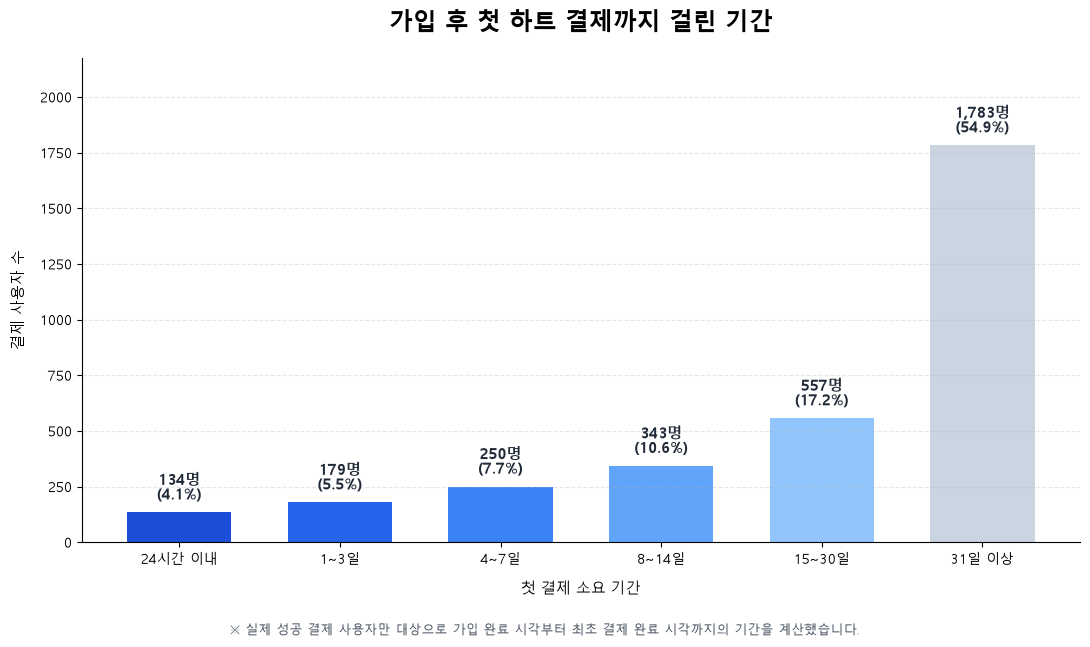

In [11]:
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 결제 소요 기간 구간 설정
# =========================================================

plot_df = first_purchase_delay_df.copy()

plot_df["days_to_first_purchase"] = pd.to_numeric(
    plot_df["days_to_first_purchase"],
    errors="coerce"
)

bins = [
    -0.001,
    1,
    3,
    7,
    14,
    30,
    np.inf
]

labels = [
    "24시간 이내",
    "1~3일",
    "4~7일",
    "8~14일",
    "15~30일",
    "31일 이상"
]

plot_df["purchase_delay_group"] = pd.cut(
    plot_df["days_to_first_purchase"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# =========================================================
# 3. 구간별 사용자 집계
# =========================================================

delay_summary = (
    plot_df["purchase_delay_group"]
    .value_counts(sort=False)
    .reindex(labels, fill_value=0)
    .reset_index()
)

delay_summary.columns = [
    "purchase_delay_group",
    "payer_count"
]

total_payers = delay_summary[
    "payer_count"
].sum()

delay_summary["payer_rate_percent"] = (
    delay_summary["payer_count"]
    / total_payers
    * 100
)


# =========================================================
# 4. 막대그래프 생성
# =========================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

colors = [
    "#1D4ED8",
    "#2563EB",
    "#3B82F6",
    "#60A5FA",
    "#93C5FD",
    "#CBD5E1"
]

bars = ax.bar(
    delay_summary["purchase_delay_group"],
    delay_summary["payer_count"],
    color=colors,
    width=0.65
)


# =========================================================
# 5. 데이터 라벨
# =========================================================

maximum_count = max(
    delay_summary["payer_count"].max(),
    1
)

for bar, count, rate in zip(
    bars,
    delay_summary["payer_count"],
    delay_summary["payer_rate_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_count * 0.025,
        f"{int(count):,}명\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 6. 그래프 설정
# =========================================================

ax.set_title(
    "가입 후 첫 하트 결제까지 걸린 기간",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "첫 결제 소요 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "결제 사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_count * 1.22
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    "※ 실제 성공 결제 사용자만 대상으로 가입 완료 시각부터 최초 결제 완료 시각까지의 기간을 계산했습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [12]:
# 어떤 행동을 많이 한 사용자가 결제로 이어지는가?
behavior_to_purchase_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at
  FROM successful_payments
  GROUP BY user_id
),

-- 가입 후 30일을 모두 관찰할 수 있는 사용자
-- 첫 7일 이내 결제자는 행동-결제 순서를 보장할 수 없어 제외
eligible_users AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    CASE
      WHEN fp.first_purchase_at
           >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
       AND fp.first_purchase_at
           < TIMESTAMP_ADD(vu.signup_at, INTERVAL 31 DAY)
      THEN 1
      ELSE 0
    END AS is_payer_30d

  FROM valid_users AS vu
  LEFT JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id
  CROSS JOIN params AS p

  WHERE DATE(vu.signup_at, 'Asia/Seoul')
        BETWEEN p.analysis_start_date
        AND DATE_SUB(p.data_end_date, INTERVAL 30 DAY)

    AND (
      fp.first_purchase_at IS NULL
      OR fp.first_purchase_at
         >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
    )
),

-- 가입 후 첫 7일 앱 접속
session_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT us.id) AS app_session_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.user_session` AS us
    ON us.user_id = eu.user_id
   AND us.started_at >= eu.signup_at
   AND us.started_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE us._source = 'local'
    AND us._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 친구 요청 발송
friend_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT fr.id) AS friend_request_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.friend_request` AS fr
    ON fr.sender_id = eu.user_id
   AND fr.created_at >= eu.signup_at
   AND fr.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE fr._source = 'local'
    AND fr._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 실제 투표와 투표 세션
vote_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vi.session_id) AS vote_session_count,
    COUNT(DISTINCT vi.id) AS vote_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi.user_id = eu.user_id
   AND vi.voted_at >= eu.signup_at
   AND vi.voted_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 후보 셔플
shuffle_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vs.id) AS shuffle_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi.user_id = eu.user_id
  INNER JOIN `ping-v2-503916.raw.vote_shuffle` AS vs
    ON vs.vote_item_id = vi.id
   AND vs.created_at >= eu.signup_at
   AND vs.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vs._source = 'local'
    AND vs._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 받은 투표 열람
received_vote_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT vr.id) AS received_vote_read_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.vote_received` AS vr
    ON vr.receiver_id = eu.user_id
   AND vr.read_at >= eu.signup_at
   AND vr.read_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE vr._source = 'local'
    AND vr._deleted_at IS NULL
    AND vr.is_read = TRUE
    AND vr.read_at IS NOT NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 하트 힌트 구매
hint_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT hp.id) AS hint_purchase_count
  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp.user_id = eu.user_id
   AND hp.created_at >= eu.signup_at
   AND hp.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 게시판 활동
board_events AS (
  SELECT author_id AS user_id, created_at
  FROM `ping-v2-503916.raw.post`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT author_id AS user_id, created_at
  FROM `ping-v2-503916.raw.post_comment`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT user_id, created_at
  FROM `ping-v2-503916.raw.post_like`
  WHERE _source = 'local'
    AND _deleted_at IS NULL

  UNION ALL

  SELECT user_id, created_at
  FROM `ping-v2-503916.raw.comment_like`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
),

board_behavior AS (
  SELECT
    eu.user_id,
    COUNT(*) AS board_action_count
  FROM eligible_users AS eu
  INNER JOIN board_events AS be
    ON be.user_id = eu.user_id
   AND be.created_at >= eu.signup_at
   AND be.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)
  GROUP BY eu.user_id
),

-- 사용자별 행동 데이터 결합
behavior_features AS (
  SELECT
    eu.user_id,
    eu.is_payer_30d,

    COALESCE(sb.app_session_count, 0)
      AS app_session_count,

    COALESCE(fb.friend_request_count, 0)
      AS friend_request_count,

    COALESCE(vb.vote_session_count, 0)
      AS vote_session_count,

    COALESCE(vb.vote_count, 0)
      AS vote_count,

    COALESCE(shb.shuffle_count, 0)
      AS shuffle_count,

    COALESCE(rvb.received_vote_read_count, 0)
      AS received_vote_read_count,

    COALESCE(hb.hint_purchase_count, 0)
      AS hint_purchase_count,

    COALESCE(bb.board_action_count, 0)
      AS board_action_count

  FROM eligible_users AS eu
  LEFT JOIN session_behavior AS sb
    ON eu.user_id = sb.user_id
  LEFT JOIN friend_behavior AS fb
    ON eu.user_id = fb.user_id
  LEFT JOIN vote_behavior AS vb
    ON eu.user_id = vb.user_id
  LEFT JOIN shuffle_behavior AS shb
    ON eu.user_id = shb.user_id
  LEFT JOIN received_vote_behavior AS rvb
    ON eu.user_id = rvb.user_id
  LEFT JOIN hint_behavior AS hb
    ON eu.user_id = hb.user_id
  LEFT JOIN board_behavior AS bb
    ON eu.user_id = bb.user_id
),

-- 행동별 세로 형태로 변환
behavior_long AS (
  SELECT
    user_id,
    is_payer_30d,
    behavior_code,
    activity_count
  FROM behavior_features
  UNPIVOT (
    activity_count FOR behavior_code IN (
      app_session_count,
      friend_request_count,
      vote_session_count,
      vote_count,
      shuffle_count,
      received_vote_read_count,
      hint_purchase_count,
      board_action_count
    )
  )
),

-- 행동 횟수 구간화
behavior_bucketed AS (
  SELECT
    user_id,
    is_payer_30d,
    behavior_code,

    CASE behavior_code
      WHEN 'app_session_count' THEN '앱 접속'
      WHEN 'friend_request_count' THEN '친구 요청 발송'
      WHEN 'vote_session_count' THEN '투표 세션'
      WHEN 'vote_count' THEN '실제 투표'
      WHEN 'shuffle_count' THEN '후보 셔플'
      WHEN 'received_vote_read_count' THEN '받은 투표 열람'
      WHEN 'hint_purchase_count' THEN '하트 힌트 구매'
      WHEN 'board_action_count' THEN '게시판 활동'
    END AS behavior_name,

    activity_count,

    CASE
      WHEN activity_count = 0 THEN '0회'
      WHEN activity_count BETWEEN 1 AND 2 THEN '1~2회'
      WHEN activity_count BETWEEN 3 AND 5 THEN '3~5회'
      WHEN activity_count BETWEEN 6 AND 10 THEN '6~10회'
      ELSE '11회 이상'
    END AS activity_group,

    CASE
      WHEN activity_count = 0 THEN 0
      WHEN activity_count BETWEEN 1 AND 2 THEN 1
      WHEN activity_count BETWEEN 3 AND 5 THEN 2
      WHEN activity_count BETWEEN 6 AND 10 THEN 3
      ELSE 4
    END AS group_order

  FROM behavior_long
),

-- 행동 구간별 결제 전환율
bucket_summary AS (
  SELECT
    behavior_code,
    behavior_name,
    activity_group,
    group_order,
    COUNT(DISTINCT user_id) AS user_count,
    COUNT(DISTINCT IF(is_payer_30d = 1, user_id, NULL))
      AS payer_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(DISTINCT IF(is_payer_30d = 1, user_id, NULL)),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS purchase_conversion_rate_percent

  FROM behavior_bucketed
  GROUP BY
    behavior_code,
    behavior_name,
    activity_group,
    group_order
),

-- 결제자와 비결제자의 평균 행동량
behavior_comparison AS (
  SELECT
    behavior_code,

    ROUND(
      AVG(IF(is_payer_30d = 1, activity_count, NULL)),
      2
    ) AS payer_avg_count,

    ROUND(
      AVG(IF(is_payer_30d = 0, activity_count, NULL)),
      2
    ) AS non_payer_avg_count

  FROM behavior_bucketed
  GROUP BY behavior_code
)

SELECT
  bs.behavior_code,
  bs.behavior_name,
  bs.activity_group,
  bs.group_order,
  bs.user_count,
  bs.payer_user_count,
  bs.purchase_conversion_rate_percent,
  bc.payer_avg_count,
  bc.non_payer_avg_count,

  ROUND(
    SAFE_DIVIDE(
      bc.payer_avg_count,
      bc.non_payer_avg_count
    ),
    2
  ) AS payer_to_nonpayer_activity_ratio

FROM bucket_summary AS bs
LEFT JOIN behavior_comparison AS bc
  USING (behavior_code)

ORDER BY
  behavior_name,
  group_order
"""

In [13]:
cost(behavior_to_purchase_sql)

예상 스캔량: 1,037.481 MiB
예상 스캔량: 1.013165 GiB
월 1 TiB 무료 용량의 약 0.09894194%


1.013165457174182

In [14]:
behavior_purchase_df = (
    bq.query(behavior_to_purchase_sql)
      .result()
      .to_dataframe()
)

behavior_purchase_df.head(20)

,behavior_code,behavior_name,activity_group,group_order,user_count,payer_user_count,purchase_conversion_rate_percent,payer_avg_count,non_payer_avg_count,payer_to_nonpayer_activity_ratio
0,board_action_count,게시판 활동,0회,0,4730,243,5.14,7.11,6.98,1.02
1,board_action_count,게시판 활동,1~2회,1,3054,173,5.66,7.11,6.98,1.02
2,board_action_count,게시판 활동,3~5회,2,2627,136,5.18,7.11,6.98,1.02
3,board_action_count,게시판 활동,6~10회,3,2208,122,5.53,7.11,6.98,1.02
4,board_action_count,게시판 활동,11회 이상,4,3922,209,5.33,7.11,6.98,1.02
5,received_vote_read_count,받은 투표 열람,0회,0,3894,230,5.91,18.90,19.32,0.98
6,received_vote_read_count,받은 투표 열람,1~2회,1,2070,119,5.75,18.90,19.32,0.98
7,received_vote_read_count,받은 투표 열람,3~5회,2,1959,97,4.95,18.90,19.32,0.98
8,received_vote_read_count,받은 투표 열람,6~10회,3,2069,91,4.40,18.90,19.32,0.98
9,received_vote_read_count,받은 투표 열람,11회 이상,4,6549,346,5.28,18.90,19.32,0.98


In [15]:
first_behavior = behavior_purchase_df[
    "behavior_name"
].iloc[0]

base_df = behavior_purchase_df[
    behavior_purchase_df["behavior_name"] == first_behavior
]

analysis_user_count = int(
    base_df["user_count"].sum()
)

payer_user_count = int(
    base_df["payer_user_count"].sum()
)

overall_conversion_rate = (
    payer_user_count
    / analysis_user_count
    * 100
)

print("[첫 7일 행동과 후속 결제 분석]")
print(
    f"분석 대상 사용자: {analysis_user_count:,}명"
)
print(
    f"가입 7일 이후부터 30일 이내 결제 사용자: "
    f"{payer_user_count:,}명 "
    f"({overall_conversion_rate:.2f}%)"
)
print(
    "※ 첫 7일 이내 이미 결제한 사용자는 "
    "행동과 결제의 시간 순서를 지키기 위해 제외했습니다."
)

[첫 7일 행동과 후속 결제 분석]
분석 대상 사용자: 16,541명
가입 7일 이후부터 30일 이내 결제 사용자: 883명 (5.34%)
※ 첫 7일 이내 이미 결제한 사용자는 행동과 결제의 시간 순서를 지키기 위해 제외했습니다.


In [16]:
comparison_df = (
    behavior_purchase_df[
        [
            "behavior_name",
            "payer_avg_count",
            "non_payer_avg_count",
            "payer_to_nonpayer_activity_ratio"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "payer_to_nonpayer_activity_ratio",
        ascending=False
    )
)

print("\n[결제자와 비결제자의 첫 7일 평균 행동량]")

for _, row in comparison_df.iterrows():

    ratio = row[
        "payer_to_nonpayer_activity_ratio"
    ]

    ratio_text = (
        f"{ratio:.2f}배"
        if pd.notna(ratio)
        else "비교 불가"
    )

    print(
        f"{row['behavior_name']}: "
        f"결제자 평균 {row['payer_avg_count']:.2f}회, "
        f"비결제자 평균 {row['non_payer_avg_count']:.2f}회 "
        f"({ratio_text})"
    )


[결제자와 비결제자의 첫 7일 평균 행동량]
후보 셔플: 결제자 평균 29.22회, 비결제자 평균 16.56회 (1.76배)
실제 투표: 결제자 평균 118.56회, 비결제자 평균 75.59회 (1.57배)
투표 세션: 결제자 평균 13.53회, 비결제자 평균 8.81회 (1.54배)
앱 접속: 결제자 평균 9.48회, 비결제자 평균 7.42회 (1.28배)
하트 힌트 구매: 결제자 평균 7.11회, 비결제자 평균 6.34회 (1.12배)
친구 요청 발송: 결제자 평균 8.46회, 비결제자 평균 7.83회 (1.08배)
게시판 활동: 결제자 평균 7.11회, 비결제자 평균 6.98회 (1.02배)
받은 투표 열람: 결제자 평균 18.90회, 비결제자 평균 19.32회 (0.98배)


In [17]:
group_order = [
    "0회",
    "1~2회",
    "3~5회",
    "6~10회",
    "11회 이상"
]

print("\n[행동량별 결제 전환율]")

for behavior_name in comparison_df["behavior_name"]:

    temp = (
        behavior_purchase_df[
            behavior_purchase_df[
                "behavior_name"
            ] == behavior_name
        ]
        .set_index("activity_group")
        .reindex(group_order)
    )

    group_text = []

    for activity_group, row in temp.iterrows():

        if pd.isna(row["user_count"]):
            continue

        group_text.append(
            f"{activity_group} "
            f"{row['purchase_conversion_rate_percent']:.2f}%"
            f"(n={int(row['user_count']):,})"
        )

    print(
        f"{behavior_name}: "
        + " → ".join(group_text)
    )


[행동량별 결제 전환율]
후보 셔플: 0회 5.04%(n=5,718) → 1~2회 4.02%(n=3,683) → 3~5회 5.62%(n=2,330) → 6~10회 5.93%(n=1,333) → 11회 이상 6.82%(n=3,477)
실제 투표: 0회 5.58%(n=3,227) → 1~2회 4.93%(n=832) → 3~5회 4.92%(n=732) → 6~10회 4.77%(n=3,770) → 11회 이상 5.59%(n=7,980)
투표 세션: 0회 5.58%(n=3,227) → 1~2회 4.85%(n=6,986) → 3~5회 4.72%(n=2,142) → 6~10회 4.89%(n=1,371) → 11회 이상 6.96%(n=2,815)
앱 접속: 0회 4.67%(n=1,414) → 1~2회 5.21%(n=6,912) → 3~5회 4.55%(n=3,359) → 6~10회 5.34%(n=1,647) → 11회 이상 6.73%(n=3,209)
하트 힌트 구매: 0회 5.11%(n=8,266) → 1~2회 5.02%(n=1,774) → 3~5회 5.65%(n=1,610) → 6~10회 4.95%(n=1,476) → 11회 이상 6.09%(n=3,415)
친구 요청 발송: 0회 4.79%(n=1,002) → 1~2회 6.12%(n=2,060) → 3~5회 4.35%(n=3,931) → 6~10회 4.91%(n=5,789) → 11회 이상 6.76%(n=3,759)
게시판 활동: 0회 5.14%(n=4,730) → 1~2회 5.66%(n=3,054) → 3~5회 5.18%(n=2,627) → 6~10회 5.53%(n=2,208) → 11회 이상 5.33%(n=3,922)
받은 투표 열람: 0회 5.91%(n=3,894) → 1~2회 5.75%(n=2,070) → 3~5회 4.95%(n=1,959) → 6~10회 4.40%(n=2,069) → 11회 이상 5.28%(n=6,549)


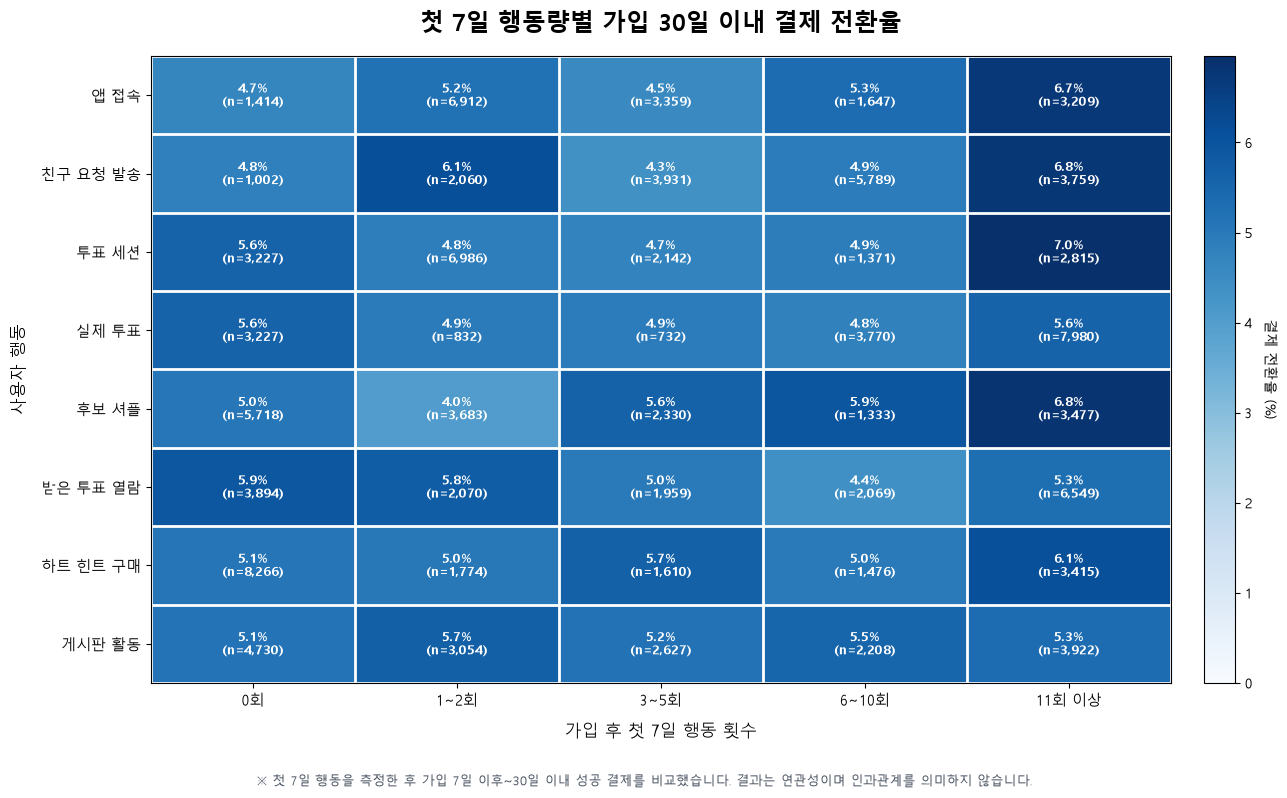

In [18]:
import platform
from copy import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 히트맵 데이터
# =========================================================

activity_order = [
    "0회",
    "1~2회",
    "3~5회",
    "6~10회",
    "11회 이상"
]

behavior_order = [
    "앱 접속",
    "친구 요청 발송",
    "투표 세션",
    "실제 투표",
    "후보 셔플",
    "받은 투표 열람",
    "하트 힌트 구매",
    "게시판 활동"
]

heatmap_df = (
    behavior_purchase_df
    .pivot_table(
        index="behavior_name",
        columns="activity_group",
        values="purchase_conversion_rate_percent",
        aggfunc="first"
    )
    .reindex(
        index=behavior_order,
        columns=activity_order
    )
)

count_df = (
    behavior_purchase_df
    .pivot_table(
        index="behavior_name",
        columns="activity_group",
        values="user_count",
        aggfunc="first"
    )
    .reindex(
        index=behavior_order,
        columns=activity_order
    )
)

heatmap_df = heatmap_df.apply(
    pd.to_numeric,
    errors="coerce"
)

count_df = count_df.apply(
    pd.to_numeric,
    errors="coerce"
)

heatmap_values = heatmap_df.to_numpy(dtype=float)
count_values = count_df.to_numpy(dtype=float)

masked_values = np.ma.masked_invalid(
    heatmap_values
)


# =========================================================
# 3. 색상
# =========================================================

cmap = copy(plt.cm.Blues)
cmap.set_bad(color="#E5E7EB")

maximum_rate = np.nanmax(heatmap_values)

if not np.isfinite(maximum_rate):
    maximum_rate = 1


# =========================================================
# 4. 시각화
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 8)
)

image = ax.imshow(
    masked_values,
    cmap=cmap,
    vmin=0,
    vmax=max(maximum_rate, 1),
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(activity_order))
)
ax.set_xticklabels(
    activity_order,
    fontsize=11
)

ax.set_yticks(
    np.arange(len(behavior_order))
)
ax.set_yticklabels(
    behavior_order,
    fontsize=11
)

ax.set_xlabel(
    "가입 후 첫 7일 행동 횟수",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "사용자 행동",
    fontsize=12,
    labelpad=10
)

ax.set_title(
    "첫 7일 행동량별 가입 30일 이내 결제 전환율",
    fontsize=17,
    fontweight="bold",
    pad=18
)


# 셀 경계선
ax.set_xticks(
    np.arange(-0.5, len(activity_order), 1),
    minor=True
)
ax.set_yticks(
    np.arange(-0.5, len(behavior_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# 셀 값 표시
for row_idx in range(len(behavior_order)):
    for col_idx in range(len(activity_order)):

        rate = heatmap_values[
            row_idx,
            col_idx
        ]

        count = count_values[
            row_idx,
            col_idx
        ]

        if np.isnan(rate):
            label = "–"
            text_color = "#6B7280"
        else:
            label = (
                f"{rate:.1f}%\n"
                f"(n={int(count):,})"
            )

            text_color = (
                "white"
                if rate >= maximum_rate * 0.55
                else "#111827"
            )

        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=text_color
        )


# 컬러바
colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

colorbar.set_label(
    "결제 전환율 (%)",
    rotation=270,
    labelpad=18
)

fig.text(
    0.5,
    0.012,
    "※ 첫 7일 행동을 측정한 후 가입 7일 이후~30일 이내 성공 결제를 비교했습니다. 결과는 연관성이며 인과관계를 의미하지 않습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [19]:
# 힌트 구매나 하트 부족 경험이 결제와 관련 있는가?
hint_balance_purchase_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date,
    200 AS minimum_hint_cost
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 성공 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at
  FROM successful_payments
  GROUP BY user_id
),

-- D30까지 관찰 가능한 사용자
-- 첫 7일 이내 결제자는 제외
eligible_users AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    CASE
      WHEN fp.first_purchase_at
           >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
       AND fp.first_purchase_at
           < TIMESTAMP_ADD(vu.signup_at, INTERVAL 31 DAY)
      THEN 1
      ELSE 0
    END AS is_payer_30d

  FROM valid_users AS vu
  LEFT JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id
  CROSS JOIN params AS p

  WHERE DATE(vu.signup_at, 'Asia/Seoul')
        BETWEEN p.analysis_start_date
        AND DATE_SUB(p.data_end_date, INTERVAL 30 DAY)

    AND (
      fp.first_purchase_at IS NULL
      OR fp.first_purchase_at
         >= TIMESTAMP_ADD(vu.signup_at, INTERVAL 7 DAY)
    )
),

-- 가입 후 첫 7일 유료 힌트 구매
hint_behavior AS (
  SELECT
    eu.user_id,
    COUNT(DISTINCT hp.id) AS hint_purchase_count,
    SUM(hp.heart_cost) AS total_hint_heart_spent

  FROM eligible_users AS eu
  INNER JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp.user_id = eu.user_id
   AND hp.created_at >= eu.signup_at
   AND hp.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL

    -- 광고로 무료 해금한 힌트가 있다면 제외
    AND hp.heart_cost > 0

  GROUP BY eu.user_id
),

-- 가입 후 첫 7일 하트 잔액 상태
heart_balance_behavior AS (
  SELECT
    eu.user_id,

    MIN(ht.balance_after) AS minimum_balance,

    COUNTIF(
      ht.balance_after < p.minimum_hint_cost
    ) AS low_balance_event_count

  FROM eligible_users AS eu

  INNER JOIN `ping-v2-503916.raw.heart_transaction` AS ht
    ON ht.user_id = eu.user_id
   AND ht.created_at >= eu.signup_at
   AND ht.created_at
       < TIMESTAMP_ADD(eu.signup_at, INTERVAL 7 DAY)

  CROSS JOIN params AS p

  WHERE ht._source = 'local'
    AND ht._deleted_at IS NULL

  GROUP BY eu.user_id
),

-- 사용자별 특징 결합
user_features AS (
  SELECT
    eu.user_id,
    eu.is_payer_30d,

    COALESCE(
      hb.hint_purchase_count,
      0
    ) AS hint_purchase_count,

    COALESCE(
      hb.total_hint_heart_spent,
      0
    ) AS total_hint_heart_spent,

    hbb.minimum_balance,

    COALESCE(
      hbb.low_balance_event_count,
      0
    ) AS low_balance_event_count,

    CASE
      WHEN COALESCE(hb.hint_purchase_count, 0) > 0
      THEN 1
      ELSE 0
    END AS has_hint_purchase,

    CASE
      WHEN COALESCE(hbb.low_balance_event_count, 0) > 0
      THEN 1
      ELSE 0
    END AS has_low_balance_proxy

  FROM eligible_users AS eu
  LEFT JOIN hint_behavior AS hb
    ON eu.user_id = hb.user_id
  LEFT JOIN heart_balance_behavior AS hbb
    ON eu.user_id = hbb.user_id
),

-- 힌트 구매 여부 × 저잔액 여부로 네 집단 구성
user_groups AS (
  SELECT
    *,

    CASE
      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 0
        THEN '힌트 없음·저잔액 없음'

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 0
        THEN '힌트 구매·저잔액 없음'

      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 1
        THEN '힌트 없음·저잔액 있음'

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 1
        THEN '힌트 구매·저잔액 있음'
    END AS user_group,

    CASE
      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 0 THEN 0

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 0 THEN 1

      WHEN has_hint_purchase = 0
       AND has_low_balance_proxy = 1 THEN 2

      WHEN has_hint_purchase = 1
       AND has_low_balance_proxy = 1 THEN 3
    END AS group_order

  FROM user_features
),

group_summary AS (
  SELECT
    user_group,
    group_order,

    COUNT(DISTINCT user_id) AS user_count,

    COUNT(
      DISTINCT IF(
        is_payer_30d = 1,
        user_id,
        NULL
      )
    ) AS payer_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_payer_30d = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS purchase_conversion_rate_percent,

    ROUND(
      AVG(hint_purchase_count),
      2
    ) AS avg_hint_purchase_count,

    ROUND(
      AVG(total_hint_heart_spent),
      2
    ) AS avg_hint_heart_spent,

    ROUND(
      AVG(minimum_balance),
      2
    ) AS avg_minimum_balance

  FROM user_groups

  GROUP BY
    user_group,
    group_order
),

-- 힌트도 없고 저잔액도 없는 집단을 기준으로 사용
reference_group AS (
  SELECT
    purchase_conversion_rate_percent
      AS reference_conversion_rate
  FROM group_summary
  WHERE group_order = 0
)

SELECT
  gs.user_group,
  gs.group_order,
  gs.user_count,
  gs.payer_user_count,
  gs.purchase_conversion_rate_percent,
  gs.avg_hint_purchase_count,
  gs.avg_hint_heart_spent,
  gs.avg_minimum_balance,

  ROUND(
    gs.purchase_conversion_rate_percent
    - rg.reference_conversion_rate,
    2
  ) AS conversion_difference_percent_point,

  ROUND(
    SAFE_DIVIDE(
      gs.purchase_conversion_rate_percent,
      rg.reference_conversion_rate
    ),
    2
  ) AS conversion_rate_ratio

FROM group_summary AS gs
CROSS JOIN reference_group AS rg

ORDER BY gs.group_order
"""

In [20]:
cost(hint_balance_purchase_sql)

예상 스캔량: 593.218 MiB
예상 스캔량: 0.579314 GiB
월 1 TiB 무료 용량의 약 0.05657365%


0.5793141378089786

In [21]:
hint_balance_purchase_df = (
    bq.query(hint_balance_purchase_sql)
      .result()
      .to_dataframe()
)

hint_balance_purchase_df

,user_group,group_order,user_count,payer_user_count,purchase_conversion_rate_percent,avg_hint_purchase_count,avg_hint_heart_spent,avg_minimum_balance,conversion_difference_percent_point,conversion_rate_ratio
0,힌트 없음·저잔액 없음,0,8320,425,5.11,0.00,0.00,403.89,0.00,1.00
1,힌트 구매·저잔액 없음,1,5299,281,5.30,5.44,111.96,356.88,0.19,1.04
2,힌트 없음·저잔액 있음,2,2,0,0.00,0.00,0.00,28.00,-5.11,0.00
3,힌트 구매·저잔액 있음,3,2920,177,6.06,22.98,479.91,53.95,0.95,1.19


In [22]:
analysis_user_count = int(
    hint_balance_purchase_df[
        "user_count"
    ].sum()
)

payer_user_count = int(
    hint_balance_purchase_df[
        "payer_user_count"
    ].sum()
)

overall_conversion_rate = (
    payer_user_count
    / analysis_user_count
    * 100
)

print("[힌트 구매·저잔액 상태와 후속 결제]")
print(
    f"분석 대상 사용자: "
    f"{analysis_user_count:,}명"
)
print(
    f"가입 7일 이후~30일 이내 결제 사용자: "
    f"{payer_user_count:,}명 "
    f"({overall_conversion_rate:.2f}%)"
)
print("-" * 75)

for _, row in (
    hint_balance_purchase_df
    .sort_values("group_order")
    .iterrows()
):
    print(
        f"{row['user_group']}: "
        f"{int(row['user_count']):,}명 중 "
        f"{int(row['payer_user_count']):,}명 결제 "
        f"({row['purchase_conversion_rate_percent']:.2f}%) | "
        f"기준 집단 대비 "
        f"{row['conversion_difference_percent_point']:+.2f}%p"
    )

[힌트 구매·저잔액 상태와 후속 결제]
분석 대상 사용자: 16,541명
가입 7일 이후~30일 이내 결제 사용자: 883명 (5.34%)
---------------------------------------------------------------------------
힌트 없음·저잔액 없음: 8,320명 중 425명 결제 (5.11%) | 기준 집단 대비 +0.00%p
힌트 구매·저잔액 없음: 5,299명 중 281명 결제 (5.30%) | 기준 집단 대비 +0.19%p
힌트 없음·저잔액 있음: 2명 중 0명 결제 (0.00%) | 기준 집단 대비 -5.11%p
힌트 구매·저잔액 있음: 2,920명 중 177명 결제 (6.06%) | 기준 집단 대비 +0.95%p


In [23]:
valid_result = hint_balance_purchase_df[
    hint_balance_purchase_df["user_count"] >= 30
].copy()

top_group = valid_result.loc[
    valid_result[
        "purchase_conversion_rate_percent"
    ].idxmax()
]

print()
print(
    f"결제 전환율이 가장 높은 집단은 "
    f"'{top_group['user_group']}'이며, "
    f"전환율은 "
    f"{top_group['purchase_conversion_rate_percent']:.2f}%입니다."
)


결제 전환율이 가장 높은 집단은 '힌트 구매·저잔액 있음'이며, 전환율은 6.06%입니다.


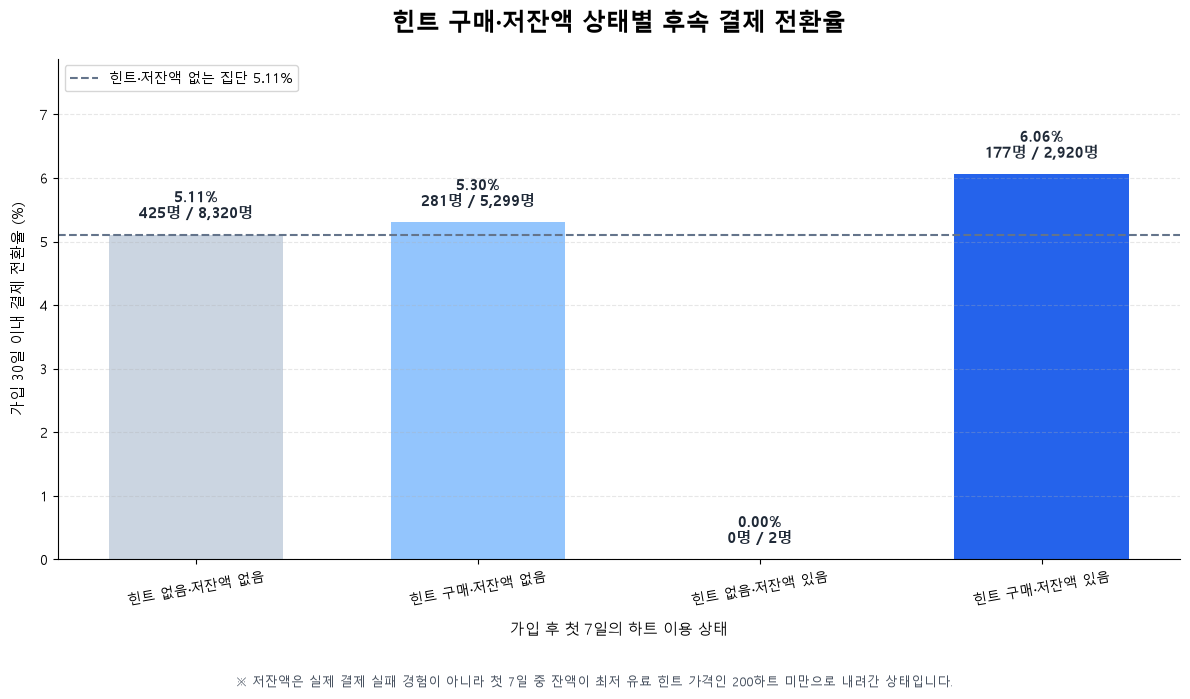

In [24]:
import platform
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화 데이터
# =========================================================

plot_df = (
    hint_balance_purchase_df
    .sort_values("group_order")
    .copy()
)

labels = plot_df["user_group"].tolist()

values = plot_df[
    "purchase_conversion_rate_percent"
].tolist()

user_counts = plot_df[
    "user_count"
].tolist()

payer_counts = plot_df[
    "payer_user_count"
].tolist()

colors = [
    "#CBD5E1",
    "#93C5FD",
    "#60A5FA",
    "#2563EB"
]


# =========================================================
# 3. 막대그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.bar(
    labels,
    values,
    color=colors[:len(labels)],
    width=0.62
)

maximum_rate = max(
    max(values),
    1
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, rate, user_count, payer_count in zip(
    bars,
    values,
    user_counts,
    payer_counts
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_rate * 0.035,
        (
            f"{rate:.2f}%\n"
            f"{int(payer_count):,}명 / "
            f"{int(user_count):,}명"
        ),
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# 기준 집단 전환율
reference_rate = float(
    plot_df.loc[
        plot_df["group_order"] == 0,
        "purchase_conversion_rate_percent"
    ].iloc[0]
)

ax.axhline(
    reference_rate,
    color="#64748B",
    linestyle="--",
    linewidth=1.5,
    label=(
        "힌트·저잔액 없는 집단 "
        f"{reference_rate:.2f}%"
    )
)


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "힌트 구매·저잔액 상태별 후속 결제 전환율",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "가입 후 첫 7일의 하트 이용 상태",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "가입 30일 이내 결제 전환율 (%)",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_rate * 1.3
)

ax.tick_params(
    axis="x",
    labelrotation=10
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.012,
    "※ 저잔액은 실제 결제 실패 경험이 아니라 첫 7일 중 잔액이 최저 유료 힌트 가격인 200하트 미만으로 내려간 상태입니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()

In [25]:
# 결제 사용자는 비결제 사용자보다 리텐션이 높은가?
payer_retention_sql = """
WITH
params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date
),

retention_periods AS (
  SELECT 1 AS period_order, 'W1' AS retention_period,
         1 AS start_day, 7 AS end_day
  UNION ALL
  SELECT 2, 'W2', 8, 14
  UNION ALL
  SELECT 3, 'W3', 15, 21
  UNION ALL
  SELECT 4, 'W4', 22, 28
),

-- 탈퇴하지 않았고 친구 5명을 확보한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 투표
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(vi.voted_at, 'Asia/Seoul') AS vote_date
  FROM `ping-v2-503916.raw.vote_item` AS vi
  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
    AND DATE(vi.voted_at, 'Asia/Seoul')
        <= p.data_end_date
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    voted_at AS first_vote_at,
    vote_date AS first_vote_date,
    session_id AS first_session_id
  FROM actual_votes
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY user_id
    ORDER BY voted_at, session_id
  ) = 1
),

-- 실제 결제 사용자
payer_users AS (
  SELECT DISTINCT
    hp.user_id
  FROM `ping-v2-503916.raw.heart_purchase` AS hp
  INNER JOIN valid_unlocked_users AS vu
    ON hp.user_id = vu.user_id
  CROSS JOIN params AS p
  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL
    AND hp.completed_at >= vu.signup_at
    AND DATE(hp.completed_at, 'Asia/Seoul')
        <= p.data_end_date
    AND hp.store_transaction_id IS NOT NULL
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )
    AND hp.price_krw > 0
    AND hp.heart_amount > 0
),

-- 활성화 사용자에게 결제 여부 부여
activated_users AS (
  SELECT
    fv.user_id,
    fv.first_vote_at,
    fv.first_vote_date,
    fv.first_session_id,

    CASE
      WHEN pu.user_id IS NOT NULL THEN '결제 사용자'
      ELSE '비결제 사용자'
    END AS payer_status,

    CASE
      WHEN pu.user_id IS NOT NULL THEN 1
      ELSE 0
    END AS is_payer

  FROM first_vote AS fv
  LEFT JOIN payer_users AS pu
    ON fv.user_id = pu.user_id
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    au.user_id,

    DATE_DIFF(
      av.vote_date,
      au.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM activated_users AS au
  INNER JOIN actual_votes AS av
    ON av.user_id = au.user_id

    -- 최초 투표 세션의 연속 투표 제외
    AND av.session_id != au.first_session_id

    -- 최초 투표 다음 날 이후만 재투표로 인정
    AND av.vote_date > au.first_vote_date

    AND DATE_DIFF(
          av.vote_date,
          au.first_vote_date,
          DAY
        ) BETWEEN 1 AND 28
),

-- 해당 주차까지 관찰할 수 있는 사용자만 포함
eligible_user_period AS (
  SELECT
    au.user_id,
    au.payer_status,
    au.is_payer,
    au.first_vote_date,
    rp.period_order,
    rp.retention_period,
    rp.start_day,
    rp.end_day

  FROM activated_users AS au
  CROSS JOIN retention_periods AS rp
  CROSS JOIN params AS p

  WHERE au.first_vote_date
        <= DATE_SUB(
          p.data_end_date,
          INTERVAL rp.end_day DAY
        )
),

-- 사용자별 기간 리텐션 여부
user_retention AS (
  SELECT
    eup.user_id,
    eup.payer_status,
    eup.is_payer,
    eup.period_order,
    eup.retention_period,
    eup.start_day,
    eup.end_day,

    CASE
      WHEN COUNTIF(
        rv.days_after_first_vote
        BETWEEN eup.start_day AND eup.end_day
      ) > 0
      THEN 1
      ELSE 0
    END AS is_retained

  FROM eligible_user_period AS eup
  LEFT JOIN return_votes AS rv
    ON rv.user_id = eup.user_id
   AND rv.days_after_first_vote
       BETWEEN eup.start_day AND eup.end_day

  GROUP BY
    eup.user_id,
    eup.payer_status,
    eup.is_payer,
    eup.period_order,
    eup.retention_period,
    eup.start_day,
    eup.end_day
),

-- 결제 여부별 리텐션
group_summary AS (
  SELECT
    period_order,
    retention_period,
    payer_status,
    is_payer,

    COUNT(DISTINCT user_id)
      AS eligible_user_count,

    COUNT(
      DISTINCT IF(
        is_retained = 1,
        user_id,
        NULL
      )
    ) AS retained_user_count,

    ROUND(
      SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_retained = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      ) * 100,
      2
    ) AS retention_rate_percent

  FROM user_retention
  GROUP BY
    period_order,
    retention_period,
    payer_status,
    is_payer
),

-- 기간별 결제자와 비결제자 차이
period_comparison AS (
  SELECT
    period_order,
    retention_period,

    MAX(
      IF(
        is_payer = 1,
        retention_rate_percent,
        NULL
      )
    ) AS payer_retention_rate,

    MAX(
      IF(
        is_payer = 0,
        retention_rate_percent,
        NULL
      )
    ) AS non_payer_retention_rate

  FROM group_summary
  GROUP BY
    period_order,
    retention_period
)

SELECT
  gs.period_order,
  gs.retention_period,
  gs.payer_status,
  gs.is_payer,
  gs.eligible_user_count,
  gs.retained_user_count,
  gs.retention_rate_percent,

  ROUND(
    pc.payer_retention_rate
    - pc.non_payer_retention_rate,
    2
  ) AS payer_difference_percent_point,

  ROUND(
    SAFE_DIVIDE(
      pc.payer_retention_rate,
      pc.non_payer_retention_rate
    ),
    2
  ) AS payer_to_nonpayer_retention_ratio

FROM group_summary AS gs
INNER JOIN period_comparison AS pc
  USING (
    period_order,
    retention_period
  )

ORDER BY
  gs.period_order,
  gs.is_payer DESC
"""

In [26]:
cost(payer_retention_sql)

예상 스캔량: 395.110 MiB
예상 스캔량: 0.385849 GiB
월 1 TiB 무료 용량의 약 0.03768061%


0.38584946375340223

In [27]:
payer_retention_df = (
    bq.query(payer_retention_sql)
      .result()
      .to_dataframe()
)

payer_retention_df

,period_order,retention_period,payer_status,is_payer,eligible_user_count,retained_user_count,retention_rate_percent,payer_difference_percent_point,payer_to_nonpayer_retention_ratio
0,1,W1,결제 사용자,1,2683,1709,63.70,8.61,1.16
1,1,W1,비결제 사용자,0,11978,6599,55.09,8.61,1.16
2,2,W2,결제 사용자,1,2654,1157,43.59,9.72,1.29
3,2,W2,비결제 사용자,0,11799,3996,33.87,9.72,1.29
4,3,W3,결제 사용자,1,2620,917,35.00,8.21,1.31
5,3,W3,비결제 사용자,0,11630,3116,26.79,8.21,1.31
6,4,W4,결제 사용자,1,2592,723,27.89,8.20,1.42
7,4,W4,비결제 사용자,0,11465,2257,19.69,8.20,1.42


In [28]:
print("[결제 사용자와 비결제 사용자의 투표 리텐션 비교]")
print(
    "기준: 최초 실제 투표 후 다른 투표 세션에서 "
    "해당 주차에 한 번 이상 재투표"
)
print("-" * 80)

for period in ["W1", "W2", "W3", "W4"]:

    period_df = payer_retention_df[
        payer_retention_df[
            "retention_period"
        ] == period
    ]

    payer_row = period_df[
        period_df["payer_status"] == "결제 사용자"
    ].iloc[0]

    non_payer_row = period_df[
        period_df["payer_status"] == "비결제 사용자"
    ].iloc[0]

    difference = float(
        payer_row[
            "payer_difference_percent_point"
        ]
    )

    ratio = float(
        payer_row[
            "payer_to_nonpayer_retention_ratio"
        ]
    )

    print(f"[{period}]")
    print(
        f"결제 사용자: "
        f"{int(payer_row['retained_user_count']):,}명 / "
        f"{int(payer_row['eligible_user_count']):,}명 "
        f"({payer_row['retention_rate_percent']:.2f}%)"
    )
    print(
        f"비결제 사용자: "
        f"{int(non_payer_row['retained_user_count']):,}명 / "
        f"{int(non_payer_row['eligible_user_count']):,}명 "
        f"({non_payer_row['retention_rate_percent']:.2f}%)"
    )
    print(
        f"결제 사용자가 비결제 사용자보다 "
        f"{difference:+.2f}%p, "
        f"{ratio:.2f}배 높습니다."
    )
    print()

[결제 사용자와 비결제 사용자의 투표 리텐션 비교]
기준: 최초 실제 투표 후 다른 투표 세션에서 해당 주차에 한 번 이상 재투표
--------------------------------------------------------------------------------
[W1]
결제 사용자: 1,709명 / 2,683명 (63.70%)
비결제 사용자: 6,599명 / 11,978명 (55.09%)
결제 사용자가 비결제 사용자보다 +8.61%p, 1.16배 높습니다.

[W2]
결제 사용자: 1,157명 / 2,654명 (43.59%)
비결제 사용자: 3,996명 / 11,799명 (33.87%)
결제 사용자가 비결제 사용자보다 +9.72%p, 1.29배 높습니다.

[W3]
결제 사용자: 917명 / 2,620명 (35.00%)
비결제 사용자: 3,116명 / 11,630명 (26.79%)
결제 사용자가 비결제 사용자보다 +8.21%p, 1.31배 높습니다.

[W4]
결제 사용자: 723명 / 2,592명 (27.89%)
비결제 사용자: 2,257명 / 11,465명 (19.69%)
결제 사용자가 비결제 사용자보다 +8.20%p, 1.42배 높습니다.



In [29]:
comparison_df = (
    payer_retention_df[
        payer_retention_df["is_payer"] == 1
    ]
    .sort_values("period_order")
)

all_higher = (
    comparison_df[
        "payer_difference_percent_point"
    ] > 0
).all()

average_difference = (
    comparison_df[
        "payer_difference_percent_point"
    ].mean()
)

if all_higher:
    conclusion = (
        "W1부터 W4까지 모든 기간에서 결제 사용자의 "
        "투표 리텐션이 비결제 사용자보다 높았습니다."
    )
else:
    conclusion = (
        "결제 사용자의 리텐션이 모든 기간에서 "
        "일관되게 높지는 않았습니다."
    )

print("[핵심 결과]")
print(conclusion)
print(
    f"네 기간의 평균 리텐션 차이는 "
    f"{average_difference:+.2f}%p입니다."
)

[핵심 결과]
W1부터 W4까지 모든 기간에서 결제 사용자의 투표 리텐션이 비결제 사용자보다 높았습니다.
네 기간의 평균 리텐션 차이는 +8.68%p입니다.


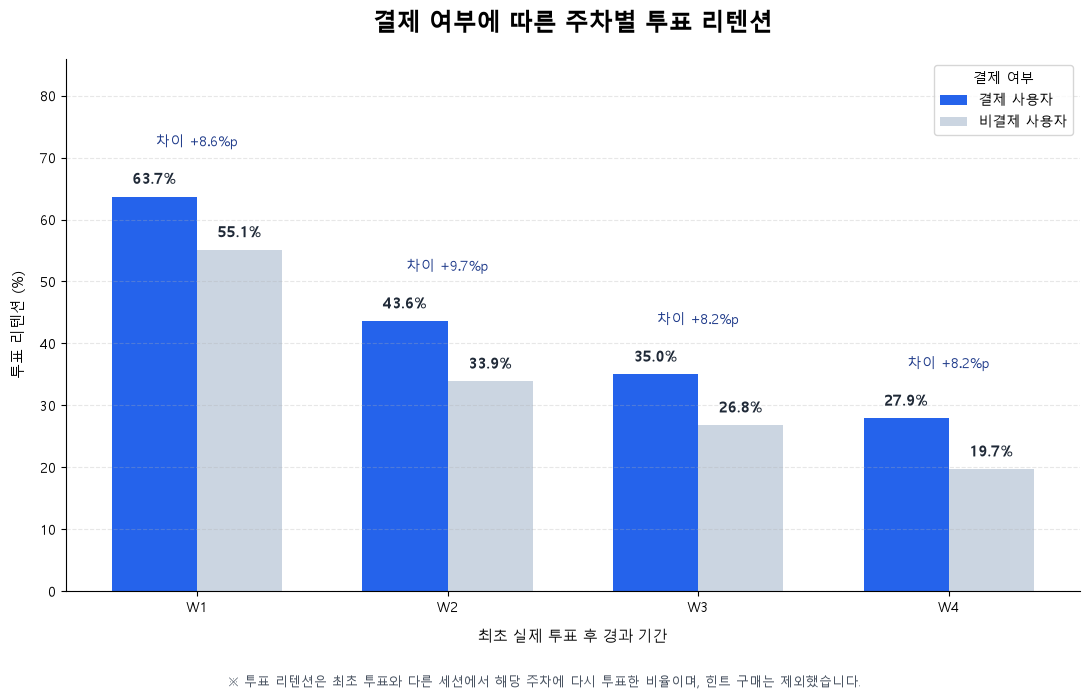

In [30]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화용 데이터
# =========================================================

period_order = [
    "W1",
    "W2",
    "W3",
    "W4"
]

plot_df = (
    payer_retention_df
    .pivot_table(
        index="retention_period",
        columns="payer_status",
        values="retention_rate_percent",
        aggfunc="first"
    )
    .reindex(period_order)
)

payer_values = (
    plot_df["결제 사용자"]
    .astype(float)
    .to_numpy()
)

non_payer_values = (
    plot_df["비결제 사용자"]
    .astype(float)
    .to_numpy()
)


# =========================================================
# 3. 그룹 막대그래프
# =========================================================

x = np.arange(
    len(period_order)
)

bar_width = 0.34

fig, ax = plt.subplots(
    figsize=(11, 7)
)

payer_bars = ax.bar(
    x - bar_width / 2,
    payer_values,
    bar_width,
    label="결제 사용자",
    color="#2563EB"
)

non_payer_bars = ax.bar(
    x + bar_width / 2,
    non_payer_values,
    bar_width,
    label="비결제 사용자",
    color="#CBD5E1"
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

maximum_rate = max(
    payer_values.max(),
    non_payer_values.max(),
    1
)

for bars, values in [
    (payer_bars, payer_values),
    (non_payer_bars, non_payer_values)
]:
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
            + maximum_rate * 0.025,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color="#1F2937"
        )


# 결제자와 비결제자 차이 표시
for index, period in enumerate(period_order):

    difference = (
        payer_values[index]
        - non_payer_values[index]
    )

    label_height = (
        max(
            payer_values[index],
            non_payer_values[index]
        )
        + maximum_rate * 0.12
    )

    ax.text(
        x[index],
        label_height,
        f"차이 {difference:+.1f}%p",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#1E3A8A"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "결제 여부에 따른 주차별 투표 리텐션",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "최초 실제 투표 후 경과 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "투표 리텐션 (%)",
    fontsize=11,
    labelpad=10
)

ax.set_xticks(x)
ax.set_xticklabels(period_order)

ax.set_ylim(
    0,
    maximum_rate * 1.35
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="결제 여부",
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.012,
    "※ 투표 리텐션은 최초 투표와 다른 세션에서 해당 주차에 다시 투표한 비율이며, 힌트 구매는 제외했습니다.",
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [38]:
# 전체 결제자 3,246명 유지하면서 31~60, 61~90, 91일 이상
first_purchase_all_payers_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date
),

-- 탈퇴하지 않은 유효 가입자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.created_at AS signup_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 성공 결제
successful_payments AS (
  SELECT
    hp.user_id,
    hp.completed_at

  FROM `ping-v2-503916.raw.heart_purchase` AS hp

  INNER JOIN valid_users AS vu
    ON hp.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE hp._source = 'local'
    AND hp._deleted_at IS NULL
    AND hp.status = 'SUCCESS'
    AND hp.completed_at IS NOT NULL

    -- 가입 이후 결제만 인정
    AND hp.completed_at >= vu.signup_at

    -- 실제 결제번호가 있는 기록
    AND hp.store_transaction_id IS NOT NULL

    -- 테스트·스텁 결제 제외
    AND NOT STARTS_WITH(
      UPPER(hp.store_transaction_id),
      'MVP-STUB-'
    )

    AND hp.price_krw > 0
    AND hp.heart_amount > 0

    AND DATE(
      hp.completed_at,
      'Asia/Seoul'
    ) BETWEEN p.analysis_start_date
          AND p.data_end_date
),

-- 사용자별 최초 실제 성공 결제
first_purchase AS (
  SELECT
    user_id,
    MIN(completed_at) AS first_purchase_at

  FROM successful_payments

  GROUP BY user_id
),

-- 가입 후 첫 결제까지 걸린 시간
purchase_delay AS (
  SELECT
    vu.user_id,
    vu.signup_at,
    fp.first_purchase_at,

    TIMESTAMP_DIFF(
      fp.first_purchase_at,
      vu.signup_at,
      HOUR
    ) AS hours_to_first_purchase,

    ROUND(
      TIMESTAMP_DIFF(
        fp.first_purchase_at,
        vu.signup_at,
        MINUTE
      ) / 1440.0,
      2
    ) AS days_to_first_purchase

  FROM valid_users AS vu

  INNER JOIN first_purchase AS fp
    ON vu.user_id = fp.user_id

  WHERE fp.first_purchase_at >= vu.signup_at
),

-- 첫 결제 소요 기간 구간화
bucketed AS (
  SELECT
    *,

    CASE
      WHEN hours_to_first_purchase <= 24
        THEN '24시간 이내'

      WHEN hours_to_first_purchase <= 72
        THEN '1~3일'

      WHEN hours_to_first_purchase <= 168
        THEN '4~7일'

      WHEN hours_to_first_purchase <= 336
        THEN '8~14일'

      WHEN hours_to_first_purchase <= 720
        THEN '15~30일'

      WHEN hours_to_first_purchase <= 1440
        THEN '31~60일'

      WHEN hours_to_first_purchase <= 2160
        THEN '61~90일'

      ELSE '91일 이상'
    END AS purchase_delay_group,

    CASE
      WHEN hours_to_first_purchase <= 24 THEN 1
      WHEN hours_to_first_purchase <= 72 THEN 2
      WHEN hours_to_first_purchase <= 168 THEN 3
      WHEN hours_to_first_purchase <= 336 THEN 4
      WHEN hours_to_first_purchase <= 720 THEN 5
      WHEN hours_to_first_purchase <= 1440 THEN 6
      WHEN hours_to_first_purchase <= 2160 THEN 7
      ELSE 8
    END AS group_order

  FROM purchase_delay
)

SELECT
  user_id,

  DATETIME(
    signup_at,
    'Asia/Seoul'
  ) AS signup_datetime_kst,

  DATETIME(
    first_purchase_at,
    'Asia/Seoul'
  ) AS first_purchase_datetime_kst,

  hours_to_first_purchase,
  days_to_first_purchase,
  purchase_delay_group,
  group_order,

  COUNT(*) OVER () AS total_payer_count

FROM bucketed

ORDER BY
  group_order,
  hours_to_first_purchase,
  user_id
"""

In [39]:
cost(first_purchase_all_payers_sql)

예상 스캔량: 1.268 MiB
예상 스캔량: 0.001238 GiB
월 1 TiB 무료 용량의 약 0.00012090%


0.0012380601838231087

In [40]:
first_purchase_all_df = (
    bq.query(first_purchase_all_payers_sql)
      .result()
      .to_dataframe()
)

first_purchase_all_df.head()

,user_id,signup_datetime_kst,first_purchase_datetime_kst,hours_to_first_purchase,days_to_first_purchase,purchase_delay_group,group_order,total_payer_count
0,2538,2025-09-12 02:57:03,2025-09-12 03:25:17,0,0.02,24시간 이내,1,3246
1,17183,2026-05-17 03:33:49,2026-05-17 03:36:11,0,0.00,24시간 이내,1,3246
2,18577,2026-06-17 01:15:53,2026-06-17 02:13:06,0,0.04,24시간 이내,1,3246
3,18889,2026-06-25 00:02:14,2026-06-25 00:46:42,0,0.03,24시간 이내,1,3246
4,19228,2026-07-03 21:05:33,2026-07-03 21:38:07,0,0.02,24시간 이내,1,3246


In [41]:
delay_order = [
    "24시간 이내",
    "1~3일",
    "4~7일",
    "8~14일",
    "15~30일",
    "31~60일",
    "61~90일",
    "91일 이상"
]

delay_summary_all = (
    first_purchase_all_df[
        "purchase_delay_group"
    ]
    .value_counts()
    .reindex(
        delay_order,
        fill_value=0
    )
    .rename_axis(
        "purchase_delay_group"
    )
    .reset_index(
        name="payer_count"
    )
)

total_payer_count = int(
    delay_summary_all["payer_count"].sum()
)

delay_summary_all["payer_share_percent"] = (
    delay_summary_all["payer_count"]
    / total_payer_count
    * 100
)

delay_summary_all


,purchase_delay_group,payer_count,payer_share_percent
0,24시간 이내,134,4.128158
1,1~3일,179,5.514479
2,4~7일,250,7.701787
3,8~14일,343,10.566852
4,15~30일,557,17.159581
5,31~60일,629,19.377696
6,61~90일,376,11.583487
7,91일 이상,778,23.967961


In [42]:
delay_days = first_purchase_all_df[
    "days_to_first_purchase"
].dropna()

average_days = delay_days.mean()
median_days = delay_days.median()

p25_days = delay_days.quantile(0.25)
p75_days = delay_days.quantile(0.75)
p90_days = delay_days.quantile(0.90)

print("[전체 결제자의 첫 결제 소요 기간]")
print(
    f"실제 결제 사용자: "
    f"{total_payer_count:,}명"
)
print(
    f"첫 결제까지 평균 소요 기간: "
    f"{average_days:.2f}일"
)
print(
    f"첫 결제까지 중앙 소요 기간: "
    f"{median_days:.2f}일"
)
print(
    f"25%는 {p25_days:.2f}일 이내, "
    f"75%는 {p75_days:.2f}일 이내, "
    f"90%는 {p90_days:.2f}일 이내에 "
    f"첫 결제를 완료했습니다."
)

print("\n[첫 결제 소요 기간별 사용자]")

for _, row in delay_summary_all.iterrows():
    print(
        f"{row['purchase_delay_group']}: "
        f"{int(row['payer_count']):,}명 "
        f"({row['payer_share_percent']:.2f}%)"
    )

[전체 결제자의 첫 결제 소요 기간]
실제 결제 사용자: 3,246명
첫 결제까지 평균 소요 기간: 60.58일
첫 결제까지 중앙 소요 기간: 36.79일
25%는 11.89일 이내, 75%는 86.82일 이내, 90%는 156.42일 이내에 첫 결제를 완료했습니다.

[첫 결제 소요 기간별 사용자]
24시간 이내: 134명 (4.13%)
1~3일: 179명 (5.51%)
4~7일: 250명 (7.70%)
8~14일: 343명 (10.57%)
15~30일: 557명 (17.16%)
31~60일: 629명 (19.38%)
61~90일: 376명 (11.58%)
91일 이상: 778명 (23.97%)


In [43]:
within_30_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 720
    ).sum()
)

within_60_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 1440
    ).sum()
)

within_90_count = int(
    (
        first_purchase_all_df[
            "hours_to_first_purchase"
        ] <= 2160
    ).sum()
)

over_90_count = (
    total_payer_count
    - within_90_count
)

print("\n[전체 결제자 기준 누적 첫 결제 비율]")

print(
    f"30일 이내: "
    f"{within_30_count:,}명 "
    f"({within_30_count / total_payer_count * 100:.2f}%)"
)

print(
    f"60일 이내: "
    f"{within_60_count:,}명 "
    f"({within_60_count / total_payer_count * 100:.2f}%)"
)

print(
    f"90일 이내: "
    f"{within_90_count:,}명 "
    f"({within_90_count / total_payer_count * 100:.2f}%)"
)

print(
    f"91일 이후: "
    f"{over_90_count:,}명 "
    f"({over_90_count / total_payer_count * 100:.2f}%)"
)


[전체 결제자 기준 누적 첫 결제 비율]
30일 이내: 1,463명 (45.07%)
60일 이내: 2,092명 (64.45%)
90일 이내: 2,468명 (76.03%)
91일 이후: 778명 (23.97%)


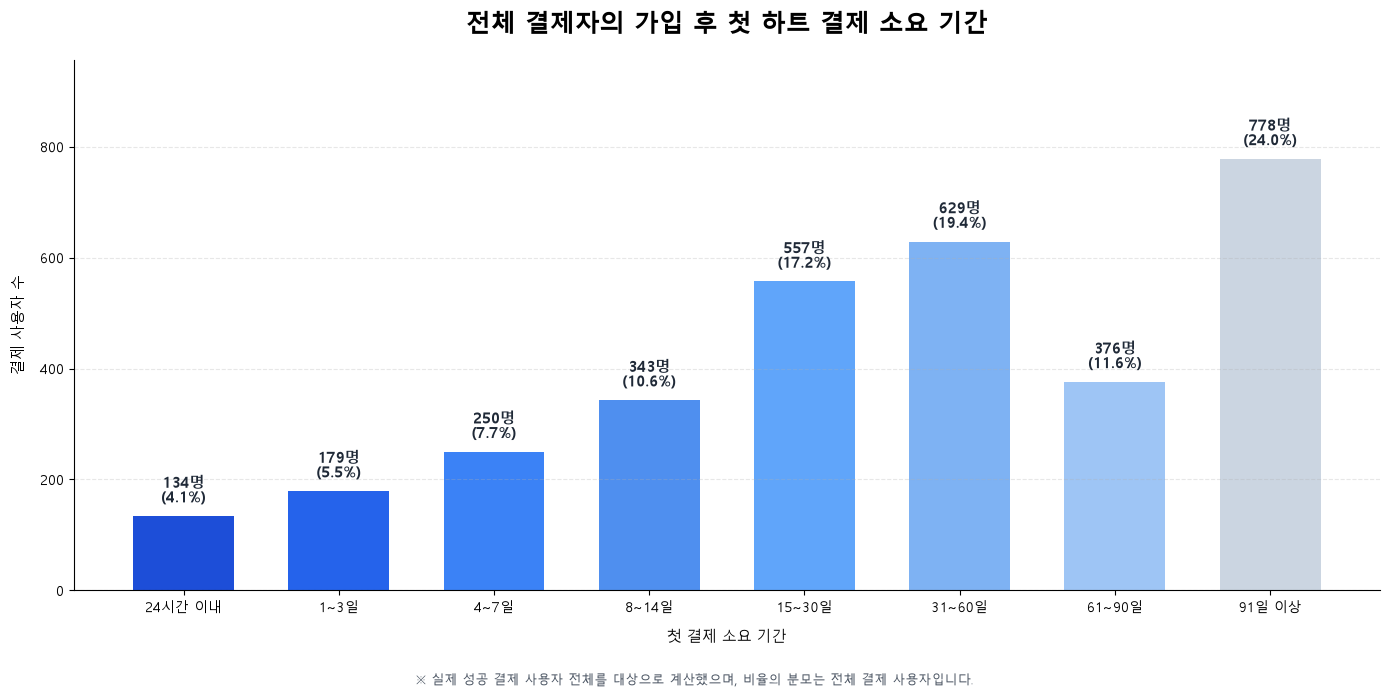

In [44]:
import platform
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화 데이터
# =========================================================

plot_df = delay_summary_all.copy()

colors = [
    "#1D4ED8",
    "#2563EB",
    "#3B82F6",
    "#4F8FEF",
    "#60A5FA",
    "#7EB2F3",
    "#9EC5F5",
    "#CBD5E1"
]


# =========================================================
# 3. 막대그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

bars = ax.bar(
    plot_df["purchase_delay_group"],
    plot_df["payer_count"],
    color=colors,
    width=0.65
)

maximum_count = max(
    int(plot_df["payer_count"].max()),
    1
)


# =========================================================
# 4. 데이터 라벨
# =========================================================

for bar, count, rate in zip(
    bars,
    plot_df["payer_count"],
    plot_df["payer_share_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + maximum_count * 0.025,
        (
            f"{int(count):,}명\n"
            f"({rate:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F2937"
    )


# =========================================================
# 5. 그래프 설정
# =========================================================

ax.set_title(
    "전체 결제자의 가입 후 첫 하트 결제 소요 기간",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "첫 결제 소요 기간",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    "결제 사용자 수",
    fontsize=11,
    labelpad=10
)

ax.set_ylim(
    0,
    maximum_count * 1.23
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.015,
    (
        "※ 실제 성공 결제 사용자 전체를 대상으로 계산했으며, "
        "비율의 분모는 전체 결제 사용자입니다."
    ),
    ha="center",
    fontsize=9.5,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()